In [474]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

In [475]:
df_dir = 'dataset/'

In [476]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = dir.name
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))
    
    return img_list

In [477]:
df = load_dataset(df_dir)

In [478]:
import matplotlib.pyplot as plt

def img_viz(img_list, num_img):
    if num_img < 0 or num_img >= len(img_list):
        raise IndexError("num_img out of range")
    
    img, label = img_list[num_img]

    img = np.array(img)

    cmap = "gray" if len(img.shape) == 2 else None

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

    print(f"Shape\t: {img.shape}")
    print(f"Label\t: {label}")


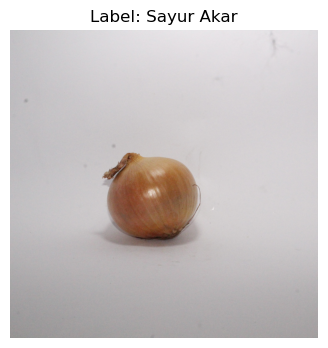

Shape	: (3456, 3456, 3)
Label	: Sayur Akar


In [479]:
img_viz(df, 0)

In [480]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

In [481]:
def segment_object_hsv(img):
    """Segmentasi menggunakan HSV color space"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Buat mask untuk objek non-hitam/putih
    lower = np.array([0, 30, 30])  # Hindari warna gelap
    upper = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    
    # # Morphological operations untuk membersihkan noise
    # kernel = np.ones((5,5), np.uint8)
    # mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    # mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Cari contour terbesar (asumsi objek adalah area terbesar)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask_final = np.zeros_like(mask)
        cv2.drawContours(mask_final, [largest_contour], -1, 255, -1)
    else:
        mask_final = mask
    
    # Apply mask
    mask3 = np.repeat(mask_final[..., None], 3, axis=2).astype("uint8") // 255
    masked_bgr = img * mask3
    masked_rgb = cv2.cvtColor(masked_bgr, cv2.COLOR_BGR2RGB)
    
    return masked_rgb

In [482]:
def preprocessing_basic(img_list):
    result = []
    for img, label in img_list:
        
        resized = cv2.resize(img, (224, 224))
        clahe = apply_clahe(resized)
        seg_mask = segment_object_hsv(clahe)   

        final_img = clahe * (seg_mask > 0)

        result.append((final_img, label))
    
    return result


In [483]:
basic = preprocessing_basic(df)

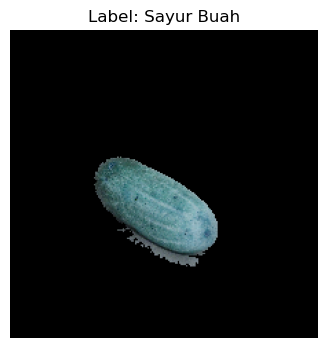

Shape	: (224, 224, 3)
Label	: Sayur Buah


In [484]:
img_viz(basic, 67)

In [485]:
def augment_img_deterministic(img):
    out = []

    out.append(img.copy())

    out.append(cv2.flip(img, 1))

    out.append(cv2.flip(img, 0))

    out.append(cv2.convertScaleAbs(img, alpha=1.2, beta=10))

    out.append(cv2.convertScaleAbs(img, alpha=0.8, beta=-10))

    h, w = img.shape[:2]
    M1 = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
    out.append(cv2.warpAffine(img, M1, (w, h)))

    M2 = cv2.getRotationMatrix2D((w//2, h//2), -15, 1)
    out.append(cv2.warpAffine(img, M2, (w, h)))

    M3 = cv2.getAffineTransform(
        np.float32([[0, 0], [w, 0], [0, h]]),
        np.float32([[0, 0], [w*1.5, 0], [0, h*1.5]])
    )
    zoomed = cv2.warpAffine(img, M3, (w, h))
    out.append(zoomed)

    return out        

In [486]:
def apply_augmentation(processed_list):
    augmented = []
    for img, label in processed_list:
        augs = augment_img_deterministic(img)
        for aug_img in augs:
            augmented.append((aug_img, label))
    return augmented


In [487]:
aug = apply_augmentation(basic)

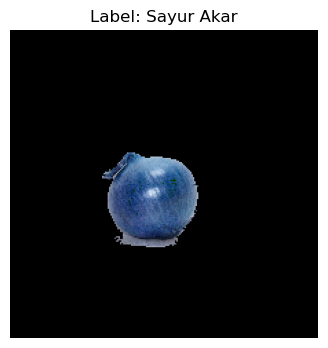

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [488]:
img_viz(aug, 0)

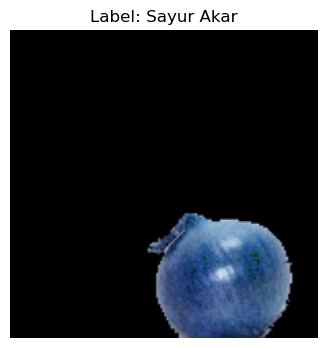

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [489]:
img_viz(aug, 7)

In [490]:
def preprocess_for_HSV(processed_list):
    result = []
    for img, label in processed_list:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        result.append((hsv, label))
    return result

In [491]:
hsv_img = preprocess_for_HSV(aug)

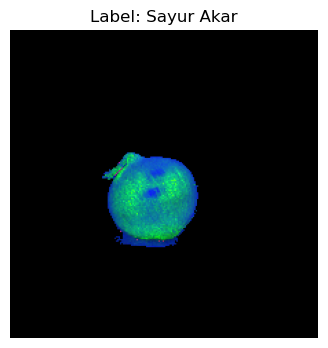

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [492]:
img_viz(hsv_img, 0)

In [493]:
def preprocess_for_GLCM(processed_list):
    result = []
    for img, label in processed_list:
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result.append((grey, label))
    return result

In [494]:
glcm_img = preprocess_for_GLCM(aug)

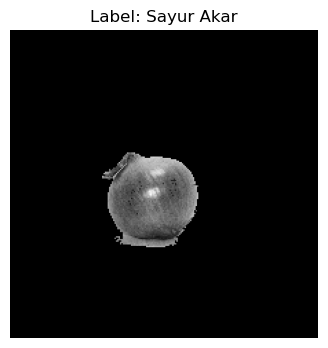

Shape	: (224, 224)
Label	: Sayur Akar


In [495]:
img_viz(glcm_img, 0)

In [496]:
def preprocess_for_HOG(processed_list):
    result = []
    for img, label in processed_list:
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(grey, (3,3), 0)
        result.append((blurred, label))
    return result

In [497]:
shape_img = preprocess_for_HOG(aug)

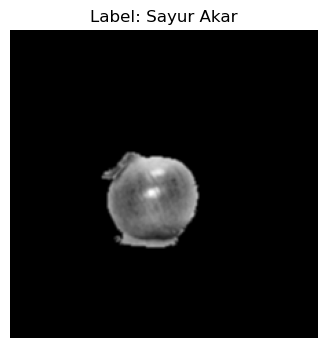

Shape	: (224, 224)
Label	: Sayur Akar


In [498]:
img_viz(shape_img, 0)

In [499]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

def extract_GLCM(img_list):
    features = []

    distances = [1, 2]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    for img, label in img_list:
        glcm = graycomatrix(img, distances=distances, angles=angles, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()

        glcm_feat = np.hstack([contrast, homogeneity, energy, correlation])
        features.append((glcm_feat, label))

    return features


In [500]:
glcm_feat = extract_GLCM(glcm_img)

In [501]:
glcm_feat[0]

(array([ 90.42064382, 130.16988075, 104.06282031, 134.30786865,
        150.93005952, 130.16988075, 178.49666184, 134.30786865,
          0.9318793 ,   0.9300403 ,   0.93211431,   0.93031931,
          0.92948967,   0.9300403 ,   0.92875446,   0.93031931,
          0.92568964,   0.92453194,   0.92548946,   0.92457217,
          0.92396735,   0.92453194,   0.92366571,   0.92457217,
          0.94928359,   0.92729141,   0.94163178,   0.92498007,
          0.91569703,   0.92729141,   0.90029953,   0.92498007]),
 'Sayur Akar')

In [502]:
from scipy.stats import skew, kurtosis, entropy

def extract_HSV_hist(img_list, bins=(8, 8, 8)):
    features = []
    
    for img, label in img_list:
        img_hsv = img
        
        img_features = []
        
        # Loop kanal warna
        for i in range(3):  # 0=H,1=S,2=V
            channel = img_hsv[:,:,i].ravel()

            mean_val = np.mean(channel)
            std_val = np.std(channel)
            var_val = np.var(channel)
            skew_val = skew(channel)
            kurt_val = kurtosis(channel)
            entr = entropy(np.histogram(channel, bins=256)[0] + 1e-7)

            img_features.extend([mean_val, std_val, var_val, skew_val, kurt_val, entr])
        
        features.append((np.array(img_features), label))
    
    return features

In [503]:
hsv_feat = extract_HSV_hist(hsv_img)

In [504]:
hsv_feat[0]

(array([8.99613361e-01, 4.19295390e+00, 1.75808624e+01, 1.72597488e+01,
        6.09589907e+02, 4.37674738e-01, 9.65864158e+00, 3.69666044e+01,
        1.36652984e+03, 3.92920456e+00, 1.47239650e+01, 6.35716627e-01,
        1.02782406e+01, 3.78436071e+01, 1.43213860e+03, 3.60338019e+00,
        1.17449206e+01, 6.08096584e-01]),
 'Sayur Akar')

In [505]:
from skimage.feature import hog

def extract_HOG(img_list):
    features = []
    for img, label in img_list:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append((hog_feat, label))
    return features


In [506]:
shape_feat = extract_HOG(shape_img)

In [507]:
shape_feat[0]

(array([0., 0., 0., ..., 0., 0., 0.], shape=(26244,)), 'Sayur Akar')

In [508]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Ekstrak hanya fitur dari list of tuples
X = np.array([feat for feat, _ in shape_feat])
y = np.array([label for _, label in shape_feat])

# Standardisasi (penting untuk PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca_hog = PCA(n_components=0.82)  # Keep 82% of variance
X_pca = pca_hog.fit_transform(X_scaled)

# Gabungkan kembali dengan label jika diperlukan
hog_features_pca = [(feat, label) for feat, label in zip(X_pca, y)]

print(f"Original HOG features shape: {X.shape}")
print(f"PCA HOG features shape: {X_pca.shape}")

Original HOG features shape: (1096, 26244)
PCA HOG features shape: (1096, 130)


In [509]:

print(f"\nhsv_feat shape: {len(hsv_feat)} samples")
print(f"hsv_feat[0][0] shape: {hsv_feat[0][0].shape}")  # shape of feature vector

print(f"\nglcm_feat shape: {len(glcm_feat)} samples")
print(f"glcm_feat[0][0] shape: {glcm_feat[0][0].shape}")  # shape of feature vector

print(f"\nshape_feat shape: {len(hog_features_pca)} samples")
print(f"shape_feat[0][0] shape: {hog_features_pca[0][0].shape}")  # shape of feature vector


hsv_feat shape: 1096 samples
hsv_feat[0][0] shape: (18,)

glcm_feat shape: 1096 samples
glcm_feat[0][0] shape: (32,)

shape_feat shape: 1096 samples
shape_feat[0][0] shape: (130,)


In [510]:
hsv_features = np.array([feat[0] for feat in hsv_feat])
glcm_features = np.array([feat[0] for feat in glcm_feat])
shape_features = np.array([feat[0] for feat in hog_features_pca])
labels = np.array([feat[1] for feat in hsv_feat])

# Combine all features horizontally
combined_features = np.hstack([hsv_features, glcm_features, shape_features])
# Create dataframe
df_features = pd.DataFrame(combined_features)
df_features['label'] = labels

print(f"Combined dataframe shape: {df_features.shape}")
print(f"Total rows: {len(df_features)}")
print(f"Features columns: {combined_features.shape[1]}")
print(df_features.head())

Combined dataframe shape: (1096, 181)
Total rows: 1096
Features columns: 180
          0         1          2          3           4         5          6  \
0  0.899613  4.192954  17.580862  17.259749  609.589907  0.437675   9.658642   
1  0.899613  4.192954  17.580862  17.259749  609.589907  0.437675   9.658642   
2  0.899613  4.192954  17.580862  17.259749  609.589907  0.437675   9.658642   
3  0.910475  4.239887  17.976639  16.794639  581.717164  0.444068   9.031409   
4  0.915976  4.591994  21.086411  19.502998  663.054469  0.437652  10.613122   

           7            8         9  ...       171       172       173  \
0  36.966604  1366.529839  3.929205  ...  1.384767 -1.090103  1.613424   
1  36.966604  1366.529839  3.929205  ...  5.911440  0.816922  1.313611   
2  36.966604  1366.529839  3.929205  ...  2.485003  3.031747 -0.075299   
3  34.552553  1193.878916  3.907105  ...  1.442441 -1.229812  1.553814   
4  40.620272  1650.006535  3.911375  ...  1.411472 -1.248064  1.516400  

In [511]:
X = df_features.drop('label', axis=1).values
y = df_features['label'].values

In [512]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [513]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [514]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [515]:
X_train_scaled

array([[-0.17265377, -0.0372333 , -0.21995898, ..., -0.44035826,
        -0.98999241, -1.6590153 ],
       [-0.84833008, -1.3111678 , -1.00193303, ...,  0.34467312,
         0.04473663, -0.63755544],
       [-0.97222488,  0.01961844, -0.17084361, ...,  0.16565459,
        -0.09145612, -0.16911135],
       ...,
       [-1.02644123, -1.53680778, -1.07684808, ..., -0.68436967,
        -0.85546864, -0.58657811],
       [-0.70861662,  1.46556944,  1.48670981, ...,  0.0104773 ,
         0.28057426,  0.13624627],
       [ 0.43771726, -0.07111389, -0.24865139, ...,  0.44286037,
         1.05352642, -0.8571657 ]], shape=(876, 180))

## Metode SVM tanpa reduksi fitur

In [516]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}


print("Parameter grid:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

svm = SVC(random_state=42)
grid_search = GridSearchCV(
    svm, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(grid_search.cv_results_['params'])}")

best_model = grid_search.best_estimator_

cv_results = pd.DataFrame(grid_search.cv_results_)
top_5 = cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(top_5.to_string(index=False))

Parameter grid:
  - C: [0.1, 1, 10, 100]
  - gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1]
  - kernel: ['rbf']
Fitting 5 folds for each of 24 candidates, totalling 120 fits



GRID SEARCH RESULTS
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9897
Total combinations tested: 24

Top 5 parameter combinations:
                                       params  mean_test_score  std_test_score  rank_test_score
  {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}         0.989721        0.004283                1
 {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}         0.987429        0.009143                2
  {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}         0.987429        0.009143                2
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}         0.987429        0.009143                2
 {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}         0.987429        0.009143                2


In [517]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       1.00      1.00      1.00        58
  Sayur Buah       1.00      1.00      1.00        53
 Sayur Bunga       0.98      1.00      0.99        48
  Sayur Daun       1.00      0.98      0.99        61

    accuracy                           1.00       220
   macro avg       0.99      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [518]:
train_acc = best_model.score(X_train_scaled, y_train)
test_acc = best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 0.9955


In [519]:
import joblib

joblib.dump(best_model, 'svm_color_texture_hogpca.joblib')

['svm_color_texture_hogpca.joblib']

## Metode KNN tanpa reduksi fitur

In [520]:
from sklearn.neighbors import KNeighborsClassifier

# =====================================
# KNN GRID SEARCH
# =====================================

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # Manhattan(1) & Euclidean(2)
    'metric': ['minkowski']
}

print("Parameter grid (KNN):")
for param, values in knn_param_grid.items():
    print(f"  - {param}: {values}")

knn = KNeighborsClassifier()

knn_grid_search = GridSearchCV(
    knn,
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

knn_grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("KNN - GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {knn_grid_search.best_params_}")
print(f"Best cross-validation score: {knn_grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(knn_grid_search.cv_results_['params'])}")

knn_best_model = knn_grid_search.best_estimator_

knn_cv_results = pd.DataFrame(knn_grid_search.cv_results_)
knn_top_5 = knn_cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(knn_top_5.to_string(index=False))


Parameter grid (KNN):
  - n_neighbors: [3, 5, 7, 9, 11]
  - weights: ['uniform', 'distance']
  - p: [1, 2]
  - metric: ['minkowski']
Fitting 5 folds for each of 20 candidates, totalling 100 fits

KNN - GRID SEARCH RESULTS
Best parameters: {'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.9897
Total combinations tested: 20

Top 5 parameter combinations:
                                                                  params  mean_test_score  std_test_score  rank_test_score
{'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}         0.989714        0.006664                1
{'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}         0.988578        0.006266                2
{'metric': 'minkowski', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}         0.987435        0.006671                3
{'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}         0.986299        0.

In [521]:
from sklearn.metrics import classification_report
y_pred = knn_best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       1.00      1.00      1.00        58
  Sayur Buah       1.00      1.00      1.00        53
 Sayur Bunga       1.00      1.00      1.00        48
  Sayur Daun       1.00      1.00      1.00        61

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [522]:
train_acc = knn_best_model.score(X_train_scaled, y_train)
test_acc = knn_best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 1.0000


In [523]:
import joblib

joblib.dump(knn_best_model, 'knn_color_texture_hogpca.joblib')

['knn_color_texture_hogpca.joblib']

## Metode Random Forest tanpa reduksi fitur

In [524]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# =====================================
# RANDOM FOREST GRID SEARCH
# =====================================

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Parameter grid (Random Forest):")
for param, values in rf_param_grid.items():
    print(f"  - {param}: {values}")

rf = RandomForestClassifier(random_state=42)

rf_grid_search = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rf_grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("RANDOM FOREST - GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(rf_grid_search.cv_results_['params'])}")

rf_best_model = rf_grid_search.best_estimator_

rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
rf_top_5 = rf_cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(rf_top_5.to_string(index=False))


Parameter grid (Random Forest):
  - n_estimators: [100, 200, 300]
  - max_depth: [None, 10, 20, 30]
  - min_samples_split: [2, 5, 10]
  - min_samples_leaf: [1, 2, 4]
  - max_features: ['sqrt', 'log2']
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

RANDOM FOREST - GRID SEARCH RESULTS
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: 0.9943
Total combinations tested: 216

Top 5 parameter combinations:
                                                                                                         params  mean_test_score  std_test_score  rank_test_score
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}         0.994286        0.007228                1
  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}         0.994286        0.007228   

In [525]:
from sklearn.metrics import classification_report
y_pred = rf_best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       1.00      1.00      1.00        58
  Sayur Buah       1.00      1.00      1.00        53
 Sayur Bunga       1.00      1.00      1.00        48
  Sayur Daun       1.00      1.00      1.00        61

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [526]:
train_acc = rf_best_model.score(X_train_scaled, y_train)
test_acc = rf_best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 1.0000


In [527]:
import joblib

joblib.dump(rf_best_model, 'rf_color_texture_hogpca.joblib')

['rf_color_texture_hogpca.joblib']

## Testing dengan gambar lain dalam dataset

In [528]:
val_dir = 'validation2/'

In [529]:
def load_dataset_without_subfolder(img_dir):
    p = Path(img_dir)
    img_list = []

    for file in p.glob("*"):
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            
            img = mpimg.imread(file)
            if img is None:
                continue

            label = file.stem   # nama file tanpa ekstensi
            img_list.append((img, label))

    return img_list

In [530]:
val_image = load_dataset_without_subfolder(val_dir)

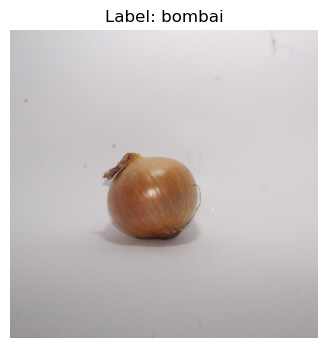

Shape	: (3456, 3456, 3)
Label	: bombai


In [531]:
img_viz(val_image, 0)

In [532]:
val_features = []
val_filenames = []

for img, filename in val_image:
    
    # preprocessing umum
    basic = preprocessing_basic([(img, "unknown")])
    
    hsv_img  = preprocess_for_HSV(basic)
    glcm_img = preprocess_for_GLCM(basic)
    shape_img = preprocess_for_HOG(basic)
    
    # Extract HOG features and reshape for PCA
    hog_features = extract_HOG(shape_img)
    shape_img_pca = pca_hog.transform(hog_features[0][0].reshape(1, -1))

    hsv_f  = extract_HSV_hist(hsv_img)[0][0]
    glcm_f = extract_GLCM(glcm_img)[0][0]
    shape_f = shape_img_pca[0]
    combined = np.hstack([hsv_f, glcm_f, shape_f])

    val_features.append(combined)
    val_filenames.append(filename)


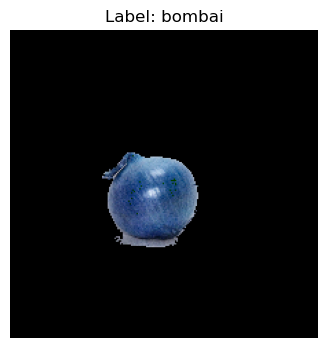

Shape	: (224, 224, 3)
Label	: bombai


In [533]:
basic_test = preprocessing_basic(val_image)
img_viz(basic_test, 0)

In [534]:
val_scaled = scaler.transform(val_features)

In [535]:
val_scaled[0]

array([-9.13996899e-01, -1.38489093e+00, -1.02851472e+00,  1.62781469e+00,
        1.89553793e+00, -8.27153313e-01, -5.90561032e-01, -2.65841335e-01,
       -3.48353221e-01,  4.25529794e-01,  1.11489286e-01, -7.74487566e-01,
       -8.16467392e-01, -4.63027102e-01, -5.69186999e-01,  3.63255436e-01,
        6.23565394e-02, -8.01836666e-01, -3.82536699e-01, -4.42484511e-01,
       -4.01320023e-01, -4.19158446e-01, -4.50324186e-01, -4.42484511e-01,
       -4.59392651e-01, -4.19158446e-01,  7.97456127e-01,  8.02289365e-01,
        7.99800792e-01,  8.05359453e-01,  8.09022177e-01,  8.02289365e-01,
        8.01885996e-01,  8.05359453e-01,  8.06799331e-01,  8.06357989e-01,
        8.04289182e-01,  8.06475136e-01,  8.08602314e-01,  8.06357989e-01,
        8.04255466e-01,  8.06475136e-01,  1.09545859e-01,  1.29614546e-01,
       -5.82494134e-03,  7.99499114e-02,  1.53521266e-01,  1.29614546e-01,
        2.22726202e-02,  7.99499114e-02,  2.86086164e-03,  1.04989929e-02,
        8.54498896e-02,  

In [536]:
svm_model = joblib.load('svm_color_texture_hogpca.joblib')
knn_model = joblib.load('knn_color_texture_hogpca.joblib')
rf_model  = joblib.load('rf_color_texture_hogpca.joblib')

svm_pred = svm_model.predict(val_scaled)
knn_pred = knn_model.predict(val_scaled)
rf_pred  = rf_model.predict(val_scaled)

In [537]:
for f, s, k, r in zip(val_filenames, svm_pred, knn_pred, rf_pred):
    print(f"{f} => SVM: {s}, KNN: {k}, RF: {r}")

bombai => SVM: 0, KNN: 0, RF: 0
brokoli => SVM: 2, KNN: 3, RF: 2
cabai => SVM: 1, KNN: 1, RF: 1
kangkung => SVM: 3, KNN: 3, RF: 3
kentang => SVM: 0, KNN: 0, RF: 0
kol => SVM: 3, KNN: 3, RF: 2
kubis => SVM: 3, KNN: 3, RF: 3
sawi_putih => SVM: 3, KNN: 3, RF: 3
timun => SVM: 1, KNN: 0, RF: 1
tomat => SVM: 0, KNN: 1, RF: 1
wortel => SVM: 0, KNN: 0, RF: 0


In [538]:
label_encoder = LabelEncoder()
label_encoder.fit(y)      # y = daftar label asli saat training

LabelEncoder()

In [539]:
svm_labels = label_encoder.inverse_transform(svm_pred)
knn_labels = label_encoder.inverse_transform(knn_pred)
rf_labels  = label_encoder.inverse_transform(rf_pred)

In [540]:
for f, s, k, r in zip(val_filenames, svm_labels, knn_labels, rf_labels):
    print(f"{f} => SVM: {s}, KNN: {k}, RF: {r}")

bombai => SVM: Sayur Akar, KNN: Sayur Akar, RF: Sayur Akar
brokoli => SVM: Sayur Bunga, KNN: Sayur Daun, RF: Sayur Bunga
cabai => SVM: Sayur Buah, KNN: Sayur Buah, RF: Sayur Buah
kangkung => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
kentang => SVM: Sayur Akar, KNN: Sayur Akar, RF: Sayur Akar
kol => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Bunga
kubis => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
sawi_putih => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
timun => SVM: Sayur Buah, KNN: Sayur Akar, RF: Sayur Buah
tomat => SVM: Sayur Akar, KNN: Sayur Buah, RF: Sayur Buah
wortel => SVM: Sayur Akar, KNN: Sayur Akar, RF: Sayur Akar


In [541]:
actual_labels = ['Sayur Akar', 'Sayur Bunga', 'Sayur Buah', 'Sayur Daun', 'Sayur Akar', 'Sayur Bunga', 'Sayur Daun', 'Sayur Daun', 'Sayur Buah', 'Sayur Buah', 'Sayur Akar'] 

In [542]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model on test set
svm_accuracy = accuracy_score(actual_labels, svm_labels) * 100
knn_accuracy = accuracy_score(actual_labels, knn_labels) * 100
rf_accuracy = accuracy_score(actual_labels, rf_labels) * 100

print("="*70)
print("MODEL ACCURACY ON TEST SET")
print("="*70)
print(f"SVM Accuracy: {svm_accuracy:.2f}%")
print(f"KNN Accuracy: {knn_accuracy:.2f}%")
print(f"RF  Accuracy: {rf_accuracy:.2f}%")
print("="*70)

MODEL ACCURACY ON TEST SET
SVM Accuracy: 81.82%
KNN Accuracy: 72.73%
RF  Accuracy: 100.00%


## Testing dengan dataset yang sudah di modifikasi

In [543]:
val2 = 'validation/'

In [544]:
val2_image = load_dataset_without_subfolder(val2)

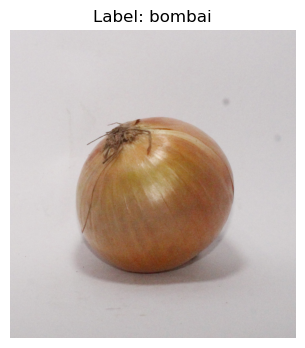

Shape	: (1906, 1768, 3)
Label	: bombai


In [545]:
img_viz(val2_image, 0)

In [546]:
val2_features = []
val2_filenames = []

for img, filename in val2_image:
    
    # preprocessing umum
    basic = preprocessing_basic([(img, "unknown")])
    
    hsv_img  = preprocess_for_HSV(basic)
    glcm_img = preprocess_for_GLCM(basic)
    shape_img = preprocess_for_HOG(basic)
    shape_img_pca = pca_hog.transform(hog_features[0][0].reshape(1, -1))

    hsv_f  = extract_HSV_hist(hsv_img)[0][0]
    glcm_f = extract_GLCM(glcm_img)[0][0]
    shape_f = shape_img_pca[0]
    combined = np.hstack([hsv_f, glcm_f, shape_f])

    val2_features.append(combined)
    val2_filenames.append(filename)

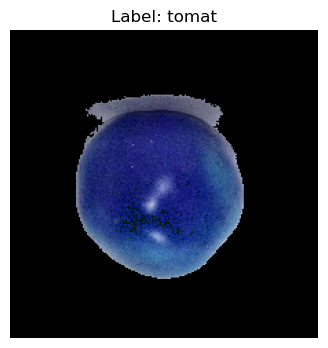

Shape	: (224, 224, 3)
Label	: tomat


In [547]:
basic_test = preprocessing_basic(val2_image)
img_viz(basic_test, 9)

In [548]:
val2_scaled = scaler.transform(val2_features)

In [549]:
val2_scaled[0]

array([-3.34134013e-01, -8.10162580e-01, -7.67177210e-01, -1.21436189e-02,
       -5.46797734e-02,  7.07820975e-01,  1.06406781e+00,  1.54216186e+00,
        1.47656159e+00, -7.76317694e-01, -6.00733286e-01,  8.28613920e-01,
        6.82363585e-01,  9.39735754e-01,  8.27176354e-01, -8.57755311e-01,
       -6.43714883e-01,  6.50577324e-01,  2.99234643e-01,  2.52907325e-01,
        2.53584739e-01,  2.62594450e-01,  2.43284653e-01,  2.52907325e-01,
        1.56942228e-01,  2.62594450e-01, -6.60773815e-01, -6.26538500e-01,
       -6.47514698e-01, -6.38128182e-01, -6.30102590e-01, -6.26538500e-01,
       -6.15601021e-01, -6.38128182e-01, -6.52385120e-01, -6.52930949e-01,
       -6.53236043e-01, -6.53136557e-01, -6.51672740e-01, -6.52930949e-01,
       -6.50266121e-01, -6.53136557e-01,  3.56275456e-01,  4.31219613e-01,
        3.94724128e-01,  4.18607548e-01,  4.15198623e-01,  4.31219613e-01,
        5.08120592e-01,  4.18607548e-01,  2.74584586e-02,  3.55344776e-03,
        9.81996722e-02,  

In [550]:
svm_pred2 = svm_model.predict(val2_scaled)
knn_pred2 = knn_model.predict(val2_scaled)
rf_pred2  = rf_model.predict(val2_scaled)

In [551]:
for f, s, k, r in zip(val2_filenames, svm_pred2, knn_pred2, rf_pred2):
    print(f"{f} => SVM: {s}, KNN: {k}, RF: {r}")

bombai => SVM: 3, KNN: 3, RF: 3
brokoli => SVM: 2, KNN: 3, RF: 3
cabai => SVM: 1, KNN: 1, RF: 1
kangkung => SVM: 3, KNN: 3, RF: 3
kentang => SVM: 3, KNN: 3, RF: 3
kol => SVM: 3, KNN: 3, RF: 3
kubis => SVM: 3, KNN: 3, RF: 3
sawi_putih => SVM: 3, KNN: 3, RF: 3
timun => SVM: 3, KNN: 3, RF: 3
tomat => SVM: 2, KNN: 3, RF: 3
wortel => SVM: 0, KNN: 0, RF: 0


In [552]:
svm_labels2 = label_encoder.inverse_transform(svm_pred2)
knn_labels2 = label_encoder.inverse_transform(knn_pred2)
rf_labels2  = label_encoder.inverse_transform(rf_pred2)

In [553]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model on test set
svm_accuracy = accuracy_score(actual_labels, svm_labels2) * 100
knn_accuracy = accuracy_score(actual_labels, knn_labels2) * 100
rf_accuracy = accuracy_score(actual_labels, rf_labels2) * 100

print("="*70)
print("MODEL ACCURACY ON TEST SET")
print("="*70)
print(f"SVM Accuracy: {svm_accuracy:.2f}%")
print(f"KNN Accuracy: {knn_accuracy:.2f}%")
print(f"RF  Accuracy: {rf_accuracy:.2f}%")
print("="*70)

MODEL ACCURACY ON TEST SET
SVM Accuracy: 54.55%
KNN Accuracy: 45.45%
RF  Accuracy: 45.45%
